Preparación de fuente de datos y librería

In [1]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Cargar el excel
ruta = '/content/drive/MyDrive/dataset_procesado.xlsx' # desde drive
df = pd.read_excel(ruta)

Mounted at /content/drive


<Figure size 1200x600 with 0 Axes>

# **Introducción**

1. Breve introducción del problema o pregunta de investigación.

    Con la base de datos la pregunta principal que surge es ¿Qué relación tiene el caudal de entrada con la calidad del agua a la salida de las plantas de tratamiento de aguas residuales -PTAR- y si la ubicación geográfica (vista como el departamento) tiene alguna influencia?

2. ¿Por qué es relevante este problema?

    La relevancia del problema radica en que el caudal es un parámetro clave en el diseño de sistemas de tratamiento de aguas residuales, donde un valor excesivo que sobrepase las capacidades de la planta puede provocar situaciones que se conocen como "lavados" y consisten en un tiempo de contacto insuficiente entre los microorganismos y la materia orgánica para la degradación de la misma. Esta situación afecta directamente la calidad del agua a la salida, donde el efluente puede no ser el adecuado para vertirlo de nuevo en los cuerpos de agua.

3. Relación entre el problema y la base de datos.

    Para abordar esa pregunta, se utiliza la base de datos del análisis de aguas después del tratamiento, proveniente del sistema único de información de servicios públicos domiciliarios, donde se reportan variables como la ubicación geográfica de las plantas, el caudal de entrada y salida, y algunos análisis fisico-químicos que ayudan a determinar la calidad del agua que ya es vertida en los cuerpos de agua.


# **Descripción de la base de datos**
A continuación se presenta una breve descripción de la base de datos, donde se observa su estructura y se presentan algunas características como la cantidad de registros, las variables, datos faltantes y los tipos de datos.

In [2]:
# Visulaizar una pequeña muestra de los datos
df.head()

,Empresa,Departamento,Municipio,Número único de identificación del sistema de tratamiento (NUPTAR),Caudal medio anual a la entrada (L/S),Caudal medio anual a la salida (LTS/SG),pH Unidades,Temperatura (°C),Sóidos Totales (mg/litro),DBO (Kg/Día),DQO (Kg/Día,Fecha de cargue
0,ACUEDUCTO ALCANTARILLADO Y ASEO DE COCONUCO S....,CAUCA,PURACE,4405,0.00,0.000,0.00,0.0,0.0,0.0,0.0,22-MAY-25
1,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2342,14.40,14.400,7.16,21.8,481.0,103.2,267.0,20-MAR-25
2,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2343,17.70,17.700,6.99,19.2,537.0,170.9,364.0,20-MAR-25
3,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2344,10.02,9.837,7.13,17.3,302.0,76.7,136.0,20-MAR-25
4,ACUEDUCTOS Y ALCANTARILLADOS SOSTENIBLES A.A.S...,ANTIOQUIA,AMALFI,2345,3.54,3.540,6.93,23.8,259.0,30.9,104.0,20-MAR-25


In [3]:
# Cantidad de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 1152
Número de variables: 12


In [4]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
float64    7
object     4
int64      1
Name: count, dtype: int64


In [5]:
# Calsificación de las variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:
- Empresa
- Departamento
- Municipio
- Fecha de cargue

🔸 Variables numéricas:
- Número único de identificación del sistema de tratamiento (NUPTAR)
- Caudal medio anual a la entrada (L/S)
- Caudal medio anual a la salida (LTS/SG)
- pH Unidades
- Temperatura (°C)
- Sóidos Totales (mg/litro)
- DBO (Kg/Día)
- DQO (Kg/Día


De la clasificación de las variables, vemos que 4 de ellas son categóricas y 8 son numéricas, sin embargo, la variable conocida como "Número único de identificación del sistema de tratamiento (NUPTAR)" también es categórica porque responde como al ID del sistema y es por eso que se debe convertir en categórica.

In [6]:
# Descripción general
df["Número único de identificación del sistema de tratamiento (NUPTAR)"] = df["Número único de identificación del sistema de tratamiento (NUPTAR)"].astype("category")
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
       Caudal medio anual a la entrada (L/S)  \
count                            1152.000000   
mean                              253.585428   
std                              3975.401596   
min                                 0.000000   
25%                                 6.220000   
50%                                24.926000   
75%                                56.897500   
max                            134168.000000   

       Caudal medio anual a la salida (LTS/SG)  pH Unidades  Temperatura (°C)  \
count                              1152.000000  1152.000000       1152.000000   
mean                                251.025847     7.071440         25.925878   
std                                3975.167750     2.132875          8.031213   
min                                   0.000000     0.000000          0.000000   
25%                                   5.725000     7.120000         22.500000   
50%                                  22.4430

In [7]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


El conteo de valores faltantes arroja que no hay valores faltantes, sin embargo, al revisar la base de datos se observan registros con valores iguales a 0.0, situación que en este contexto se interpretaría como un valor faltante.

In [8]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
Municipio                                                             241
Número único de identificación del sistema de tratamiento (NUPTAR)    227
Caudal medio anual a la salida (LTS/SG)                               182
Caudal medio anual a la entrada (L/S)                                 173
DQO (Kg/Día                                                           165
DBO (Kg/Día)                                                          164
Temperatura (°C)                                                      156
Sóidos Totales (mg/litro)                                             152
pH Unidades                                                           142
Empresa                                                               108
Fecha de cargue                                                        91
Departamento                                                           25
dtype: int64


# **Visualizaciones exploratorias**

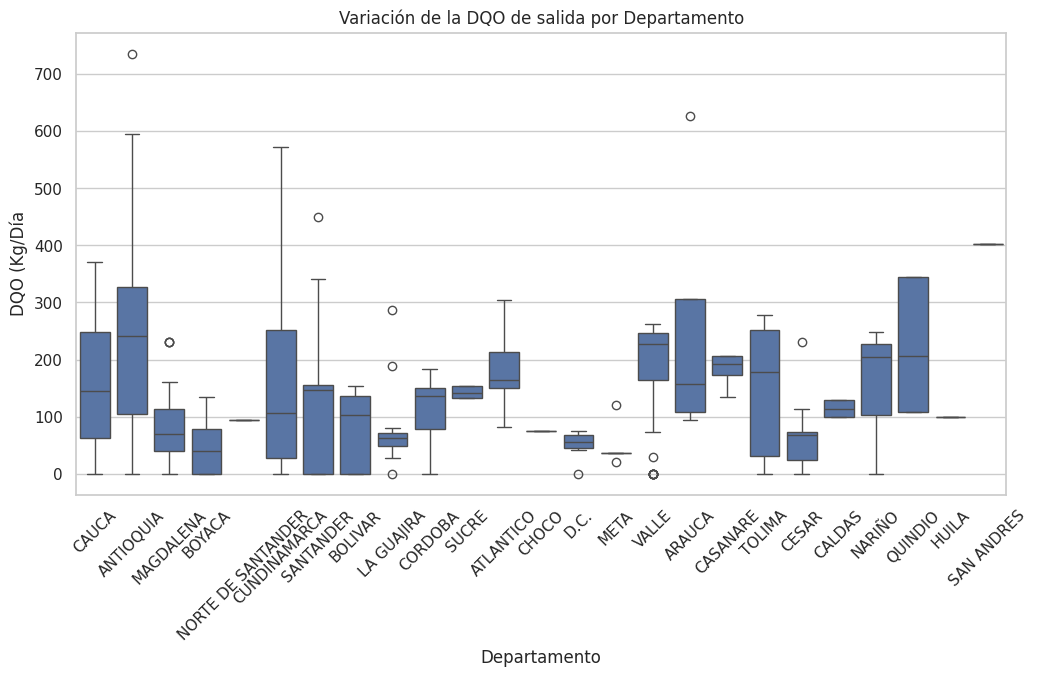

In [9]:
# 1. Boxplot por Departamento para ver influencia geográfica
plt.figure(figsize=(12,6))
sns.boxplot(x='Departamento', y='DQO (Kg/Día', data=df)
plt.xticks(rotation=45)
plt.title('Variación de la DQO de salida por Departamento')
plt.show()

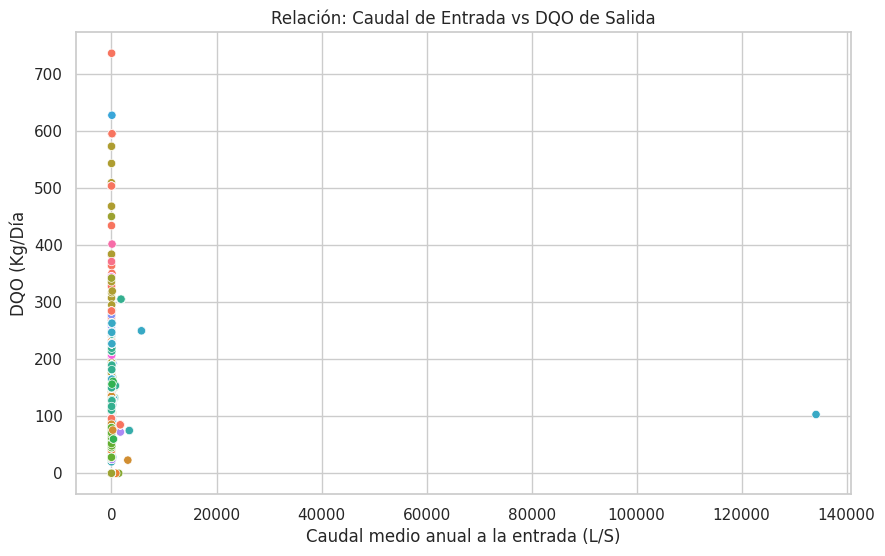

In [10]:
# 2. Scatter Plot para ver relación Caudal vs Calidad
plt.figure(figsize=(10,6))
sns.scatterplot(x='Caudal medio anual a la entrada (L/S)', y='DQO (Kg/Día', data=df, hue='Departamento', legend=None) # Se quitó la leyenda de los datos que corresponde a los departamentos porque invade el gráfico, sin embargo, sigue siendo de mucha importancia
plt.title('Relación: Caudal de Entrada vs DQO de Salida')
plt.show()

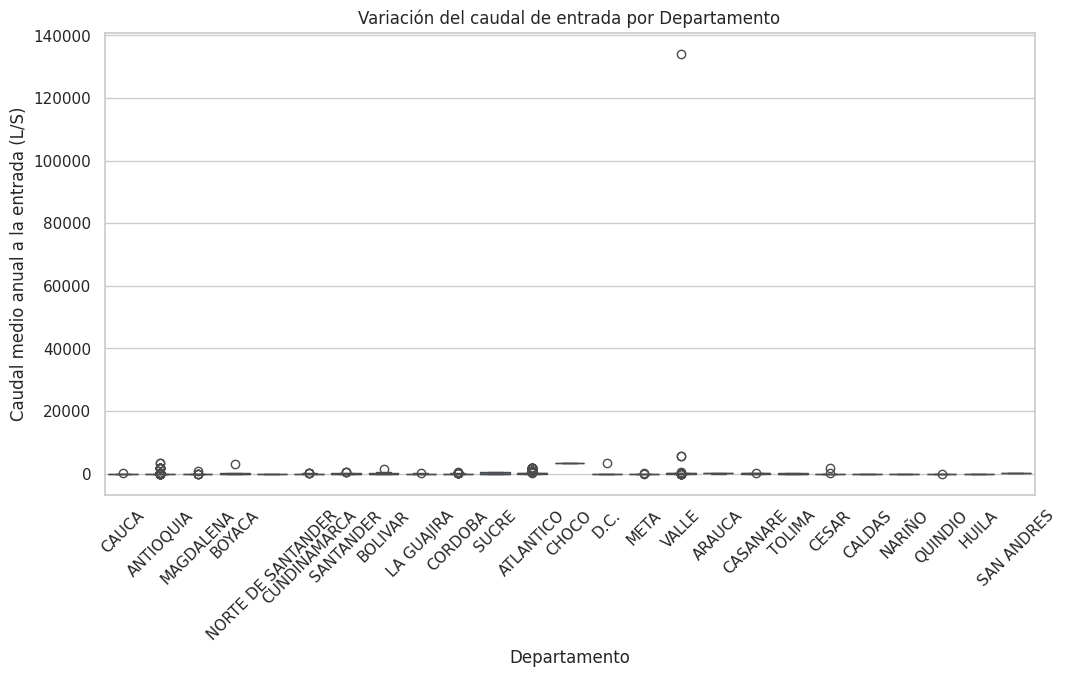

In [11]:
# 3. Boxplot por Departamento para ver influencia geográfica
plt.figure(figsize=(12,6))
sns.boxplot(x='Departamento', y='Caudal medio anual a la entrada (L/S)', data=df)
plt.xticks(rotation=45)
plt.title('Variación del caudal de entrada por Departamento')
plt.show()

# **Interpretaciones iniciales**

- Patrones o tendencias que se observan:
  - De la descripción de las variables se observa que hay gran dispersión en variables como el caudal a la entrada y a la salida de las plantas de agua, esto nos indica que no hay una distinción entre planta de poca y alta capacidad.
  - El pH presenta poca variabilidad, lo que nos indicaría que este parámetro fisicoquímico en las plantas de tratamiento se encuentra en valores adecuados para el vertido de las aguas.
  - Como en la base de datos se encuentran registros de 25 departamentos diferentes a los cuales pertenecen los 241 municipios, lso cuales se encuentran en diferentes regiones del país, con condiciones climáticas diferentes, es de esperar la varibilidad de que presenta la temperatura.
  - En parámetros como los sólidos totales, la DBO y la DQO se observa alta variabilidad, lo que genera interés debido a que estos son los parámetros clave para evaluar la carga orgánica de las aguas residuales y por consiguiente su calidad.
  - Se observan algunos outliers en las gráficas, donde se hace pertinente considerar el uso de filtrado para tratar esos datos atípicos separados de los demás y así reducir el ruido.

- Limitaciones de la base de datos:

  - La primera limitación que se evidencia en la base de datos es que no se tiene claridad de si las plantas que registran los valores son todas diferentes o son las mismas (en el caso donde pertenencen al mismo municipio)
  - No se abarca todo el territorio nacional, lo que pone una limitante debido a que de los 32 departamentos, se encuentran registros de 25 departamentos y solo de 241 municipios de un total de 1123 a nivel nacional.
  - Como se mencionó en el apartado donde se calcularon los datos faltantes, en el registro no se dejaron los espaciosn vacíos, si no que se les asignó un valor de 0.0. Si bien, esta situación hace pensar que no faltan datos, en el contexto de los datos, un valor de 0.0 en los parámetros fisicoquímicos se interpreta como un valor faltante por lo que es necesario reemplazar esos valores por espacios vacíos para el posterior análisis.

- Posibles hipótesis:

  - La ubicación de la planta se relaciona con la calidad de los efluentes de salida.
  - El caudal registrado no se puede relacionar con la calidad del agua a la salida de la planta.
  - Pueden existir relaciones entre la temperatura del efluente (que genralmente es la temperatura ambiente) con la calidad del agua tratada.

# **Referencias**

Fuente de datos: Sistema único de información de servivios públicos   domiciliarios (SUI).

url: http://reportes.sui.gov.co/fabricaReportes/frameSet.jsp?idreporte=alc_tec_005